In [1]:
# Autoload modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
import sys
sys.path.append('..')
from fcc import MiyazawaJerniganInteraction, Peptide, ProteinFoldingProblem, PenaltyParameters, ProteinFoldingResult
from fcc.fcc_protein_shape import ProteinShapeDecoder, ProteinShapeFileGen
from vqe import VQEC, PerturbedPrimalDualOpt, OptimisticGDAOpt, VQECResult
from qiskit import QuantumCircuit
from qiskit.circuit.library import RealAmplitudes, EfficientSU2, TwoLocal
from qiskit.primitives import Sampler
# from qiskit_aer.primitives import Estimator, Sampler
from qiskit_aer.primitives import Estimator
from qiskit_algorithms.gradients import LinCombEstimatorGradient, ParamShiftEstimatorGradient, FiniteDiffEstimatorGradient
import numpy as np
import matplotlib.pyplot as plt
from qufold.execution_utils.measurements import _evaluate_sparsepauli
from qiskit.quantum_info import SparsePauliOp
import json
import os

In [14]:
def build_pf(main_seq: str, energy_matrix_file: str = "mj_matrix"):
    """Builds the protein folding problem for the given sequence."""

    mj_interaction = MiyazawaJerniganInteraction(energy_matrix_file)
    print(mj_interaction.calculate_energy_matrix(main_seq))

    penalty_back = 50
    penalty_redun = 50
    penalty_olap = None

    penalty_terms = PenaltyParameters(
        penalty_back=penalty_back,
        penalty_redun=penalty_redun,
        penalty_olap=penalty_olap,
    )

    peptide = Peptide(main_seq)

    protein_folding_problem = ProteinFoldingProblem(
        peptide, mj_interaction, penalty_terms
    )

    return protein_folding_problem


def check_overlaps(peptide: Peptide, bitstring: str) -> None | list[tuple[int, int]]:
    """Check the overlaps of the given bitstring."""
    # Convert the bitstring to the set of turns 
    psd = ProteinShapeDecoder(peptide=peptide, solution_bitstring=bitstring)
    turn_seq = psd.turn_sequence
    psfg = ProteinShapeFileGen(peptide=peptide, turn_sequence=turn_seq)
    # Get the coordinates of the beads
    coords = psfg.generate_amino_acid_positions()
    # Check for overlaps
    overlaps = []
    for i in range(len(coords)):
        for j in range(i + 1, len(coords)):
            if np.isclose(np.linalg.norm(coords[i] - coords[j]), 0.0):
                overlaps.append((i, j))
    if len(overlaps) > 0:
        return overlaps
    # If no overlaps, return None
    return None

## Single run workflow

In [4]:
main_seq = "KLVFFA" # 6MVZ ("LFLF")YYDPETGTWY
protein_folding_problem = build_pf(main_seq)
qubit_op = protein_folding_problem.qubit_op()
print(f"Number of qubits: {qubit_op.num_qubits}")
print(f"Number of terms: {len(qubit_op)}")

[[ 0.   -3.37 -2.49 -3.36 -3.36 -1.31]
 [ 0.    0.   -6.48 -7.28 -7.28 -4.91]
 [ 0.    0.    0.   -6.29 -6.29 -4.04]
 [ 0.    0.    0.    0.   -7.26 -4.81]
 [ 0.    0.    0.    0.    0.   -4.81]
 [ 0.    0.    0.    0.    0.    0.  ]]
Number of qubits: 24
Number of terms: 2199


In [5]:
bead_pairs, olap_constr_ops = protein_folding_problem.olap_constr_ops()
print(f"Number of overlap constraints: {len(olap_constr_ops)}")
print(f"Number of qubits: {olap_constr_ops[0].num_qubits}")

Number of overlap constraints: 6
Number of qubits: 24


### Perturbed primal-dual method

In [49]:
ansatz = TwoLocal(
    qubit_op.num_qubits,
    ["ry"],
    "cx",
    reps=1,
    entanglement="linear",
    skip_final_rotation_layer=True,
)
estimator = Estimator(
    backend_options={"method": "matrix_product_state"},
    run_options={"shots": None},
    approximation=True,
)
# estimator = Estimator()
gradient = ParamShiftEstimatorGradient(estimator=estimator)

init_dual_vars = np.array([0.0] * len(olap_constr_ops))
perturb_step = 0.05
gamma = 0.1
max_iter = 800

vqec = PerturbedPrimalDualOpt(
    qubit_op=qubit_op,
    constr_ops=olap_constr_ops,
    ansatz=ansatz,
    estimator=estimator,
    gradient=gradient,
)

vqec_result = vqec.optimize_primal_dual(
    initial_dual_vars=init_dual_vars,
    primal_perturb_step=perturb_step,
    dual_perturb_step=perturb_step,
    gamma=gamma,
    auto_update_step=False,
    max_iter=max_iter,
)

print(vqec_result.optimal_primal_vars)
print(vqec_result.optimal_dual_vars)
print(f"Optimal energy: {vqec_result.energies[-1]}")

100%|██████████| 800/800 [1:07:05<00:00,  5.03s/it]

[6.28276012e+00 2.74688678e+00 1.03560190e+00 3.14159265e+00
 6.28318531e+00 3.14159265e+00 6.28317226e+00 3.14159265e+00
 3.14168330e+00 2.68119931e-07 9.88051158e-03 6.28300754e+00
 9.10234587e-02 6.28318531e+00 4.01986610e-02 6.18126949e+00
 3.09173389e+00 3.34226721e+00 3.37936058e+00 6.23596069e+00
 3.12996749e+00 3.23251303e+00 6.20278929e+00 7.30866684e-02]
[0. 0. 0. 0. 0. 0.]
Optimal energy: -0.33412658154731734


In [57]:
vqec_result.constraints

array([[-3.55283159, -6.38819151, -6.77674217, -4.33506939, -5.97713091,
        -3.7282602 ],
       [-2.07829754, -4.99264001, -6.07693457, -4.50769071, -6.97141914,
        -4.19710651],
       [-0.75037638, -3.35717194, -5.03976147, -4.1480325 , -7.35365799,
        -4.31856701],
       ...,
       [-1.20994182, -3.05463145, -3.25523577, -0.94074595, -0.08730191,
        -0.94609471],
       [-1.20993786, -3.05462269, -3.25523345, -0.9407574 , -0.08730538,
        -0.94608026],
       [-1.20993394, -3.05461402, -3.25523115, -0.94076875, -0.08730882,
        -0.94606597]])

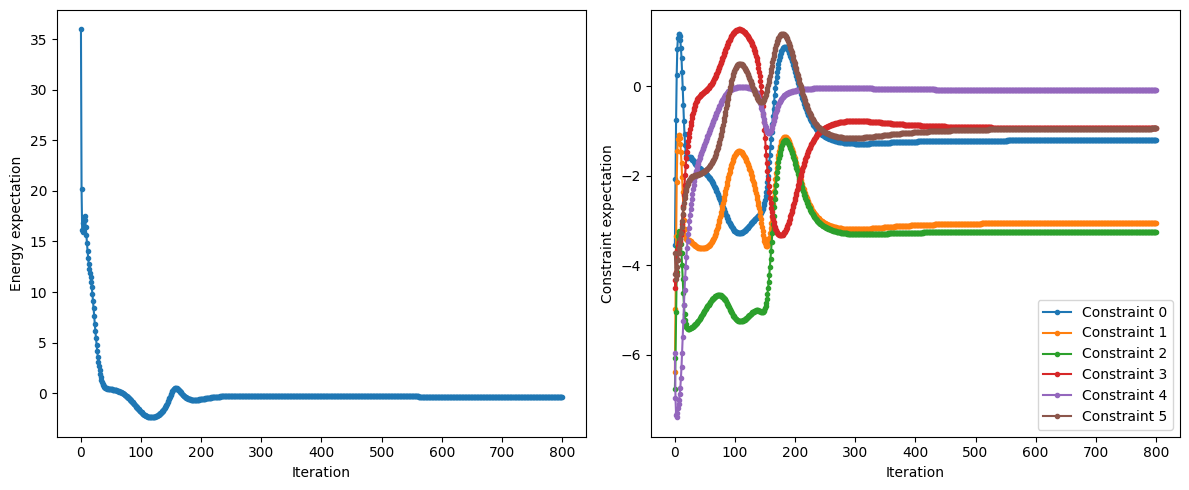

In [60]:
# Plot the results
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(vqec_result.energies, label="Energy", marker=".")
ax[0].set_xlabel("Iteration")
ax[0].set_ylabel("Energy expectation")

for i, constr_op in enumerate(olap_constr_ops):
    ax[1].plot(
        vqec_result.constraints[:, i],
        label=f"Constraint {i}",
        marker=".",
    )
ax[1].set_xlabel("Iteration")
ax[1].set_ylabel("Constraint expectation")
ax[1].legend()

# ax[2].plot(vqec_result.lagrangian_gap_trajectory, label="Dual", marker=".")
# ax[2].set_xlabel("Iteration")
# ax[2].set_ylabel("Lagrangian gap trajectory")

plt.tight_layout()
plt.show()

In [52]:
full_circ = vqec_result.ansatz.copy()
full_circ.measure_all()
sampler = Sampler(options={"shots": 50000})
# sampler = Sampler(run_options={"shots": 10000})
sampler_result = sampler.run(circuits=[full_circ], parameter_values=vqec_result.optimal_primal_vars).result()
quasi_dist = sampler_result.quasi_dists[0].binary_probabilities()

# Sort the binary strings by their probabilities
sorted_quasi_dist = dict(sorted(quasi_dist.items(), key=lambda item: item[1], reverse=True))
# Compute the energies of all samples
from qufold.execution_utils.measurements import _evaluate_sparsepauli
bitstring_energies = {}
for i, (sample, prob) in enumerate(sorted_quasi_dist.items()):
    if i >= 5:
        break
    energy = _evaluate_sparsepauli(sample, qubit_op)
    bitstring_energies[sample] = energy
    print(f"Sample {i}: {sample} with probability {prob} and energy {energy}")

/var/folders/f0/3f43g55s7jj8xnhyp1dq2nfh0000gn/T/ipykernel_5287/2057137825.py:3: DeprecationWarning: The class ``qiskit.primitives.sampler.Sampler`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseSamplerV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Sampler` class is `StatevectorSampler`.
  sampler = Sampler(options={"shots": 50000})


Sample 0: 000100101111111101100110 with probability 0.70092 and energy -0.011000000000002536
Sample 1: 111011010000000010011010 with probability 0.2262 and energy -1.202000000000001
Sample 2: 111011010000000010011000 with probability 0.02876 and energy -5.570000000000003
Sample 3: 111011101111111101100110 with probability 0.0106 and energy 0.24199999999999738
Sample 4: 000100101111111101100100 with probability 0.009 and energy 10.605


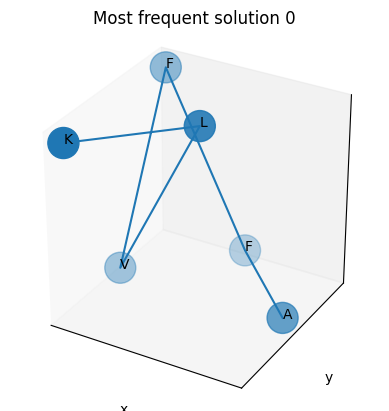

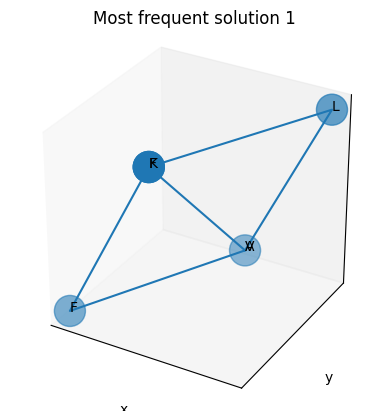

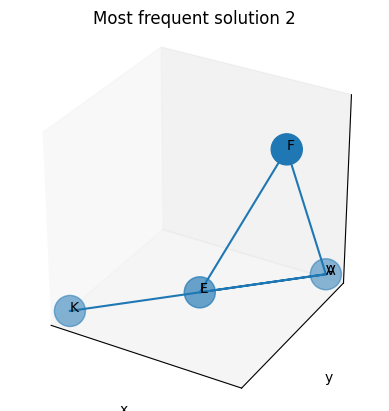

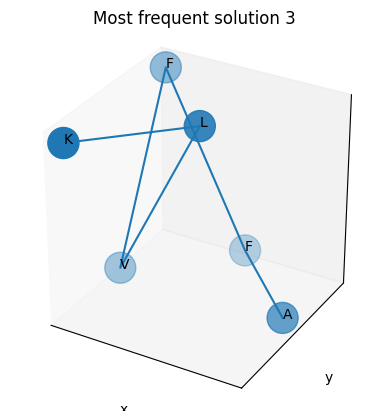

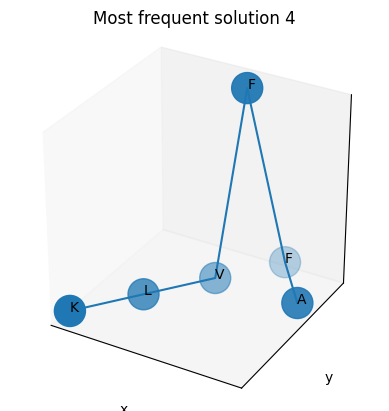

In [53]:
for i, (sample, energy) in enumerate(bitstring_energies.items()):
    pf_result = ProteinFoldingResult(peptide=protein_folding_problem.peptide, unused_qubits=protein_folding_problem.unused_qubits, solution_bitstring=sample)
    fig = pf_result.get_figure(title=f"Most frequent solution {i}")
    plt.show()

### Optimistic gradient descent-ascent method

In [9]:
ansatz = TwoLocal(
    qubit_op.num_qubits,
    ["ry"],
    "cx",
    reps=1,
    entanglement="linear",
    skip_final_rotation_layer=True,
)
estimator = Estimator(
    backend_options={"method": "matrix_product_state"},
    run_options={"shots": None},
    approximation=True,
)
# estimator = Estimator()
gradient = ParamShiftEstimatorGradient(estimator=estimator)

init_dual_vars = np.array([0.0] * len(olap_constr_ops))
step_size = 0.05
max_iter = 300

vqec = OptimisticGDAOpt(
    qubit_op=qubit_op,
    constr_ops=olap_constr_ops,
    ansatz=ansatz,
    estimator=estimator,
    gradient=gradient,
)

vqec_result = vqec.optimize_primal_dual(
    initial_dual_vars=init_dual_vars,
    step_size=step_size,
    max_iter=max_iter,
)

100%|██████████| 300/300 [23:42<00:00,  4.74s/it]


In [10]:
print(f"Optimal energy: {vqec_result['energy_history'][-1]}")

Optimal energy: 4.223879469513965


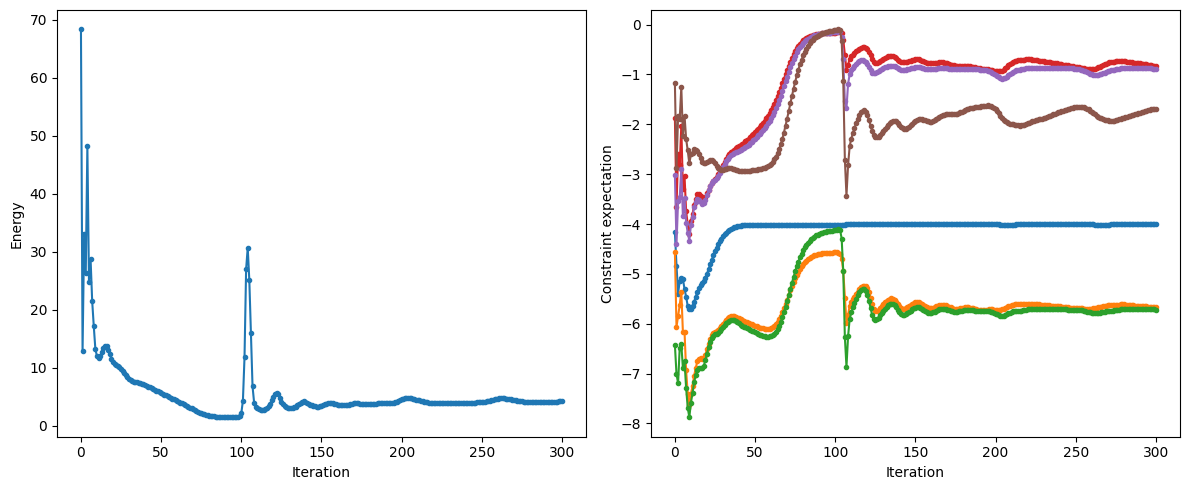

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(vqec_result['energy_history'], marker=".")
ax[0].set_xlabel("Iteration")
ax[0].set_ylabel("Energy")

ax[1].plot(vqec_result['constraints_history'], marker=".")
ax[1].set_xlabel("Iteration")
ax[1].set_ylabel("Constraint expectation")

plt.tight_layout()
plt.show()

In [16]:
peptide = Peptide(main_seq)

In [17]:
full_circ = ansatz.copy()
full_circ.measure_all()
sampler = Sampler(options={"shots": 10000})
# sampler = Sampler(run_options={"shots": 10000})
sampler_result = sampler.run(circuits=[full_circ], parameter_values=vqec_result['optimal_primal_vars']).result()
quasi_dist = sampler_result.quasi_dists[0].binary_probabilities()

# Sort the binary strings by their probabilities
sorted_quasi_dist = dict(sorted(quasi_dist.items(), key=lambda item: item[1], reverse=True))
# Compute the energies of all samples
from qufold.execution_utils.measurements import _evaluate_sparsepauli
bitstring_energies = {}
for i, (sample, prob) in enumerate(sorted_quasi_dist.items()):
    if i >= 5:
        break
    energy = _evaluate_sparsepauli(sample, qubit_op)
    # Check for overlaps
    overlaps = check_overlaps(peptide, sample)
    bitstring_energies[sample] = energy
    print(f"Sample {i}: {sample} with probability {prob}, energy {energy}, and overlaps {overlaps}")

/var/folders/6z/68dj05v5057cwh6yv32zx6380000gp/T/ipykernel_48050/2866115732.py:3: DeprecationWarning: The class ``qiskit.primitives.sampler.Sampler`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseSamplerV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Sampler` class is `StatevectorSampler`.
  sampler = Sampler(options={"shots": 10000})


Sample 0: 100110001111100001110111 with probability 0.0597, energy 0.5189999999999851, and overlaps None
Sample 1: 011001110000011110001000 with probability 0.0541, energy 0.22599999999998677, and overlaps None
Sample 2: 011001110000011111110111 with probability 0.0476, energy 5.912000000000002, and overlaps None
Sample 3: 100110001111100000001000 with probability 0.0428, energy 4.447000000000003, and overlaps None
Sample 4: 011001110111100001110111 with probability 0.0378, energy 1.8189999999999835, and overlaps None


## Parallelized runs workflow

In [22]:
import ray

In [23]:
@ray.remote
def _optimize_ray(
    ppd_opt: PerturbedPrimalDualOpt,
    init_params: np.ndarray | None = None,
    init_dual_vars: np.ndarray | None = None,
    primal_perturb_step: float = 0.05,
    dual_perturb_step: float = 0.05,
    primal_dual_update_step: float = 1,
    max_iter: int = 300,
) -> VQECResult:
    """Optimize the given problem using the Perturbed Primal Dual method."""
    return ppd_opt.optimize_primal_dual(
        initial_params=init_params,
        initial_dual_vars=init_dual_vars,
        primal_perturb_step=primal_perturb_step,
        dual_perturb_step=dual_perturb_step,
        gamma=primal_dual_update_step,
        max_iter=max_iter,
    )

In [27]:
ray.shutdown()

In [24]:
import psutil
import vqe

num_cpus = psutil.cpu_count(logical=False)
print(f"Number of CPUs: {num_cpus}")
ray.init(
    ignore_reinit_error=True,
    num_cpus=num_cpus,
    runtime_env={
        "py_modules": [vqe],
    },
)

Number of CPUs: 12


2025-05-02 16:31:30,233	INFO worker.py:1772 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8265 
2025-05-02 16:31:30,251	INFO packaging.py:530 -- Creating a file package for local directory '/Users/lir9/protein-folding-qc/notebooks/../vqe'.
2025-05-02 16:31:30,264	INFO packaging.py:358 -- Pushing file package 'gcs://_ray_pkg_bd531a8483bea683.zip' (0.07MiB) to Ray cluster...
2025-05-02 16:31:30,265	INFO packaging.py:371 -- Successfully pushed file package 'gcs://_ray_pkg_bd531a8483bea683.zip'.


Python version:,3.12.2
Ray version:,2.34.0
Dashboard:,http://127.0.0.1:8265


100%|██████████| 5/5 [00:25<00:00,  5.08s/it]


In [26]:
# num_opt_runs = 4
max_iter = 5
update_steps = [0.1, 0.5, 1.0, 2.0]

ansatz = TwoLocal(
    qubit_op.num_qubits,
    ["ry"],
    "cx",
    reps=1,
    entanglement="linear",
    skip_final_rotation_layer=True,
)
estimator = Estimator(
    backend_options={"method": "matrix_product_state"},
    run_options={"shots": None},
    approximation=True,
)
# estimator = Estimator()
gradient = ParamShiftEstimatorGradient(estimator=estimator)

vqec = PerturbedPrimalDualOpt(
    qubit_op=qubit_op,
    constr_ops=olap_constr_ops,
    ansatz=ansatz,
    estimator=estimator,
    gradient=gradient,
)
res = ray.get(
    [
        _optimize_ray.remote(
            ppd_opt=vqec,
            init_params=None,
            init_dual_vars=None,
            primal_perturb_step=0.05,
            dual_perturb_step=0.05,
            primal_dual_update_step=update_step,
            max_iter=max_iter,
        )
        for update_step in update_steps
    ]
)

In [27]:
for i, r in enumerate(res):
    r.write_to_json(f"vqec_run_{i}.json")

## HPC data postprocessing

In [4]:
from fcc.fcc_protein_shape import ProteinShapeDecoder, ProteinShapeFileGen

In [5]:
def check_overlaps(peptide: Peptide, bitstring: str) -> None | list[tuple[int, int]]:
    """Check the overlaps of the given bitstring."""
    # Convert the bitstring to the set of turns
    psd = ProteinShapeDecoder(peptide=peptide, solution_bitstring=bitstring)
    turn_seq = psd.turn_sequence
    psfg = ProteinShapeFileGen(peptide=peptide, turn_sequence=turn_seq)
    # Get the coordinates of the beads
    coords = psfg.generate_amino_acid_positions()
    # Check for overlaps
    overlaps = []
    for i in range(len(coords)):
        for j in range(i + 1, len(coords)):
            if np.isclose(np.linalg.norm(coords[i] - coords[j]), 0.0):
                overlaps.append((i, j))
    if len(overlaps) > 0:
        return overlaps
    # If no overlaps, return None
    return None


def exists_top_solns(turn: str, top_cls_turns: list[str]) -> bool:
    """Check if the given turn exists in the top solutions given by classical exhaustive search."""
    # Check if the turn exists in the top turns
    for i, top_cls_turn in enumerate(top_cls_turns):
        if turn == top_cls_turn[0]:
            return i
    return None


def sample_optimized_circ(
    ansatz: QuantumCircuit, optimized_params: np.ndarray, shots: int
) -> dict[str, float]:
    """Sample the optimized circuit and return the quasi distribution."""
    # Create a copy of the ansatz
    full_circ = ansatz.copy()
    # Measure all qubits
    full_circ.measure_all()
    # Create a sampler
    sampler = Sampler(options={"shots": shots})
    # Run the sampler
    sampler_result = sampler.run(
        circuits=[full_circ], parameter_values=optimized_params
    ).result()
    # Get the quasi distribution
    quasi_dist = sampler_result.quasi_dists[0].binary_probabilities()
    # Sort the binary strings by their probabilities
    sorted_quasi_dist = dict(
        sorted(quasi_dist.items(), key=lambda item: item[1], reverse=True)
    )
    return sorted_quasi_dist

In [6]:
cs_dir = "../classical_search/cs_res/"


def relabel_turns(turns: str) -> str:
    """Relabels the turns from the classical search to the ones used in the quantum search."""
    mapping = {
        "0": "0",
        "1": "2",
        "2": "4",
        "3": "6",
        "4": "8",
        "5": "a",
        "6": "1",
        "7": "3",
        "8": "5",
        "9": "7",
        "a": "9",
        "b": "b",
    }
    return "".join([mapping[turn] for turn in turns])


def load_top_cls_solns(file_name: str) -> list[str]:
    top_cls_turns = []
    with open(cs_dir + file_name, "r") as file:
        data = file.read()
        # Split by line
        data_by_line = data.split("\n")
        for line in data_by_line:
            if len(line.split("\t")) == 2:
                [energy, turns] = line.split("\t")
                top_cls_turns.append([relabel_turns(turns), float(energy)])
    return top_cls_turns


def convert_bitstring_to_turns(soln_bitstring: str, main_seq: str) -> str:
    """Converts a solution bitstring (given by the quantum algorithm) to the
    turns."""
    encoding = {
        "0000": "0",
        "0011": "1",
        "1100": "2",
        "1111": "3",
        "1001": "4",
        "0101": "5",
        "1010": "6",
        "0110": "7",
        "1000": "8",
        "0100": "9",
        "1011": "a",
        "0111": "b",
        "0001": "x",  # unphysical
        "0010": "x",  # unphysical
        "1101": "x",  # unphysical
        "1110": "x",  # unphysical
    }
    peptide_len = len(main_seq)
    config_bitstring = soln_bitstring[-(4 * peptide_len - 10) :]
    # Add the first 4 bits corresponding to the fixed first turn (0000)
    full_config_bitstring = config_bitstring + "0000"
    # Add the two qubits at positions 6 & 7 from the right (00)
    full_config_bitstring = (
        full_config_bitstring[:-6] + "00" + full_config_bitstring[-6:]
    )
    # Reverse the bitstring
    full_config_bitstring = full_config_bitstring[::-1]
    length_turns = len(full_config_bitstring) // 4
    turns = ""
    for i in range(length_turns):
        turn = full_config_bitstring[i * 4 : (i + 1) * 4]
        turns += encoding[turn]
    # Reverse the turns
    return turns[::-1]


cls_file_name = "6AA_KLVFFA_topobj.txt"
top_cls_turns = load_top_cls_solns(cls_file_name)[:50]
top_cls_turns

[['97490', -30.57],
 ['a9720', -30.55],
 ['8b520', -30.55],
 ['70b90', -30.45],
 ['81490', -30.45],
 ['31a20', -30.43],
 ['31820', -30.43],
 ['2b580', -30.43],
 ['9a180', -30.43],
 ['5b580', -30.33],
 ['1a180', -30.33],
 ['68b90', -30.25],
 ['02180', -30.23],
 ['70390', -30.13],
 ['68390', -30.13],
 ['82180', -30.13],
 ['07490', -30.13],
 ['7b090', -29.56],
 ['91820', -29.56],
 ['b1a20', -29.56],
 ['20390', -29.36],
 ['90390', -29.26],
 ['0a120', -29.24],
 ['08120', -29.24],
 ['2a120', -29.14],
 ['28120', -29.14],
 ['86390', -29.14],
 ['07a90', -29.14],
 ['49720', -29.14],
 ['6b520', -29.14],
 ['30720', -29.12],
 ['30520', -29.12],
 ['6a180', -29.12],
 ['80520', -29.12],
 ['a0720', -29.12],
 ['41820', -29.02],
 ['3b580', -29.02],
 ['50520', -29.02],
 ['61a20', -29.02],
 ['70720', -29.02],
 ['81820', -29.02],
 ['90520', -29.02],
 ['a1a20', -29.02],
 ['b0720', -29.02],
 ['7a180', -29.02],
 ['1b090', -28.69],
 ['46390', -28.37],
 ['a0b90', -28.37],
 ['61490', -28.27],
 ['90b90', -28.27]]

In [7]:
main_seq = "KLVFFA" # 6MVZ ("LFLF")YYDPETGTWY
peptide = Peptide(main_seq)
bitstring_test = "101111101101100000101011"
check_overlaps(peptide, bitstring_test)

[(1, 5)]

[[ 0.   -3.37 -2.49 -3.36 -3.36 -1.31]
 [ 0.    0.   -6.48 -7.28 -7.28 -4.91]
 [ 0.    0.    0.   -6.29 -6.29 -4.04]
 [ 0.    0.    0.    0.   -7.26 -4.81]
 [ 0.    0.    0.    0.    0.   -4.81]
 [ 0.    0.    0.    0.    0.    0.  ]]


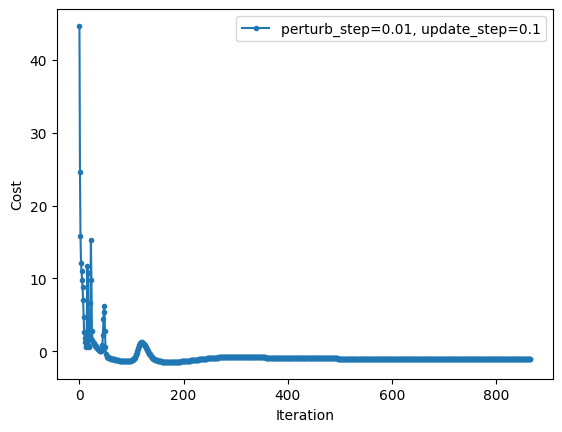

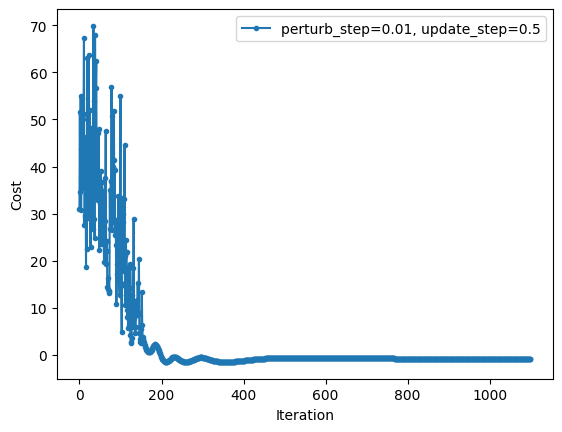

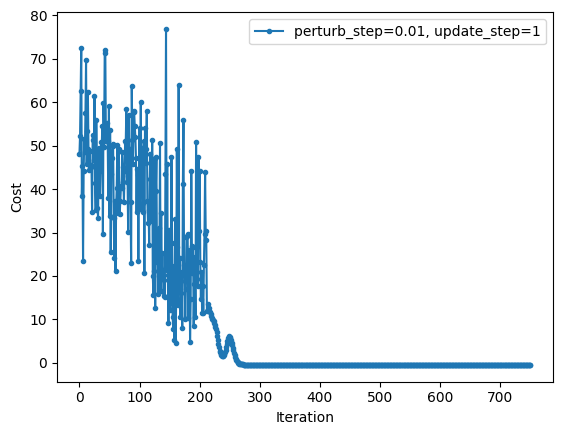

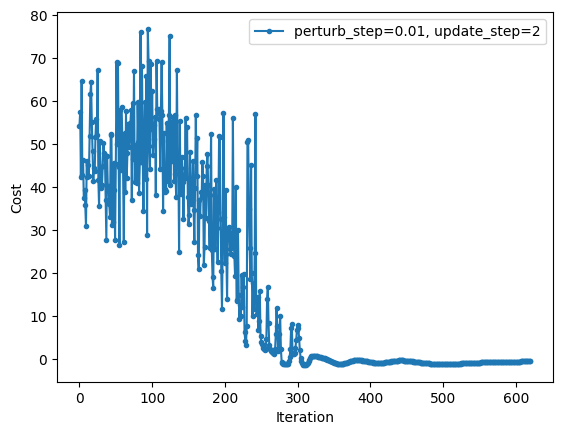

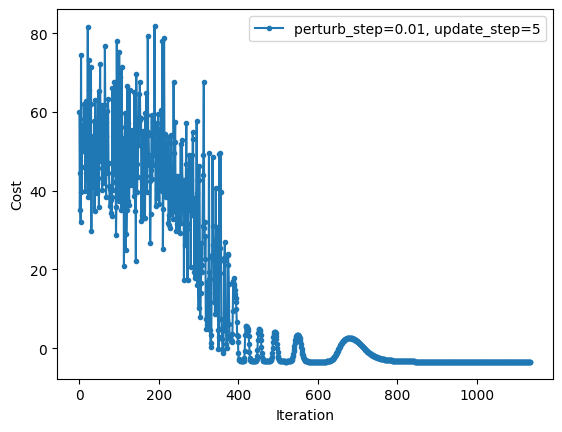

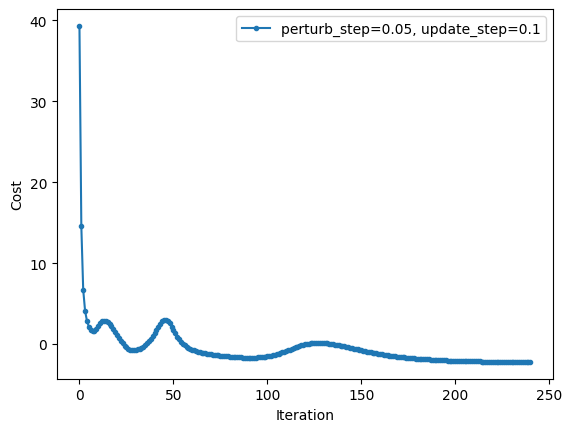

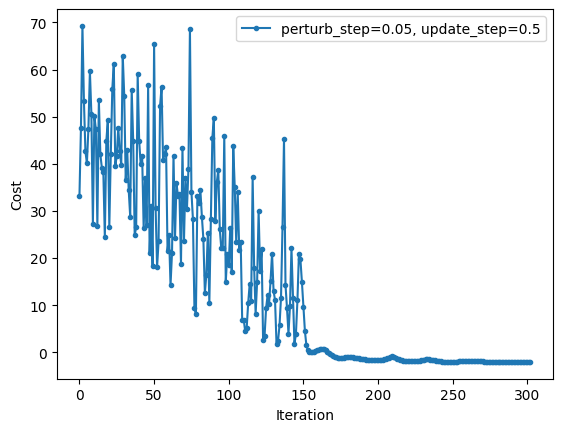

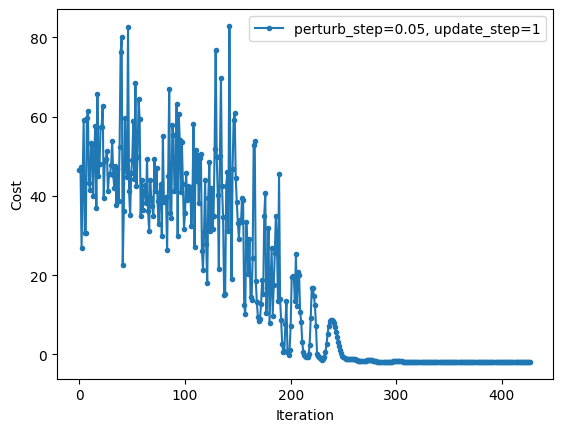

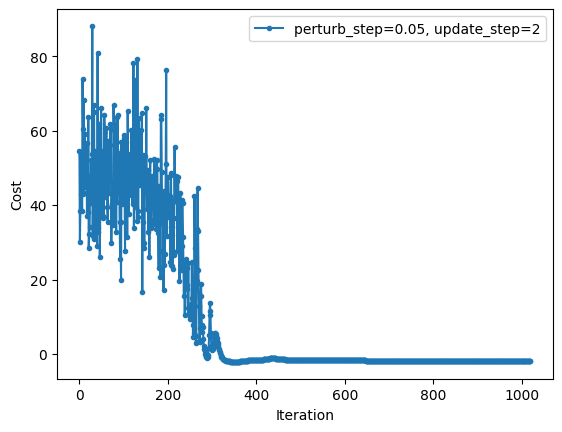

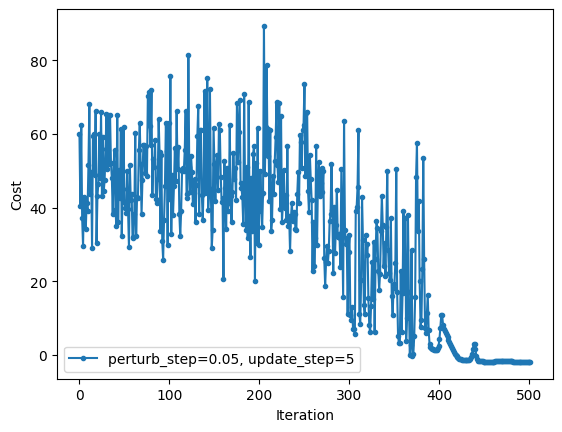

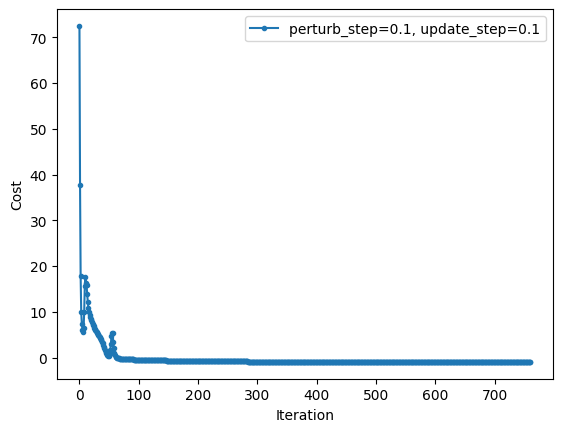

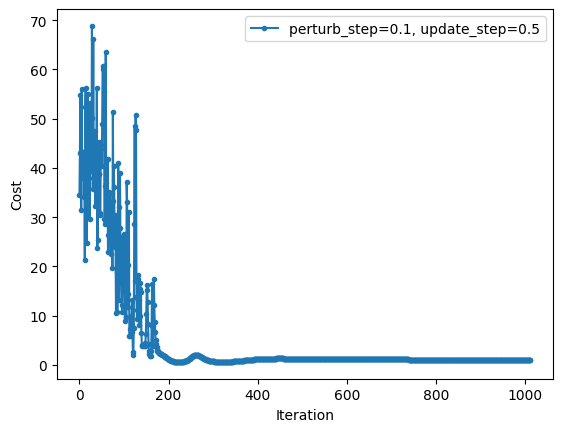

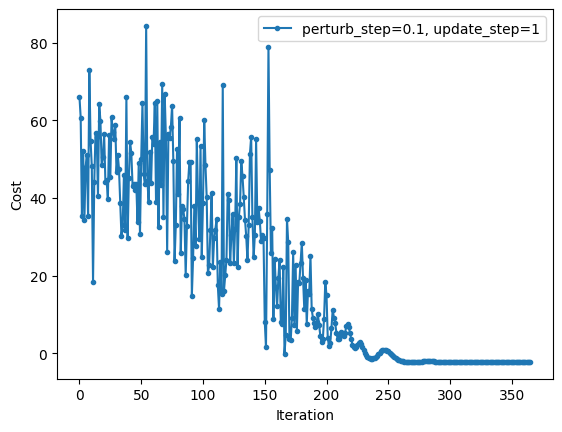

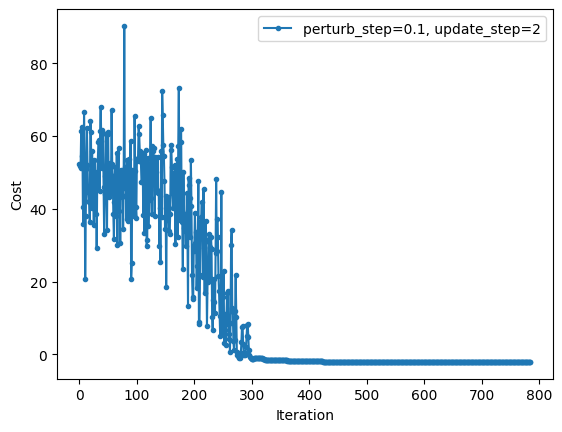

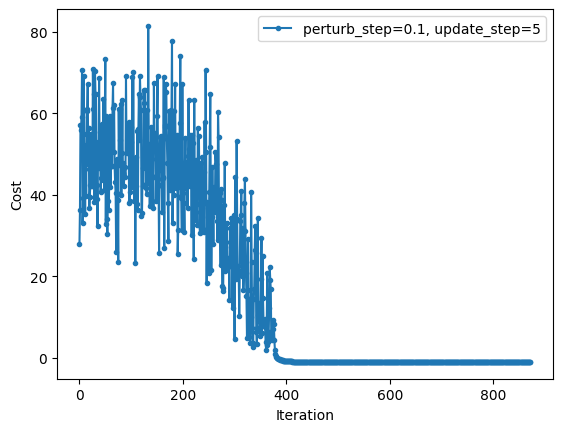

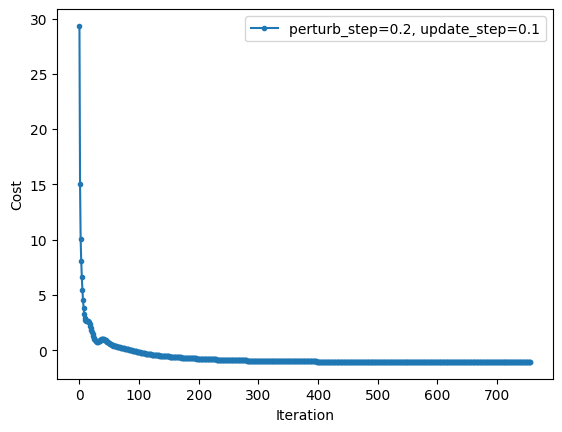

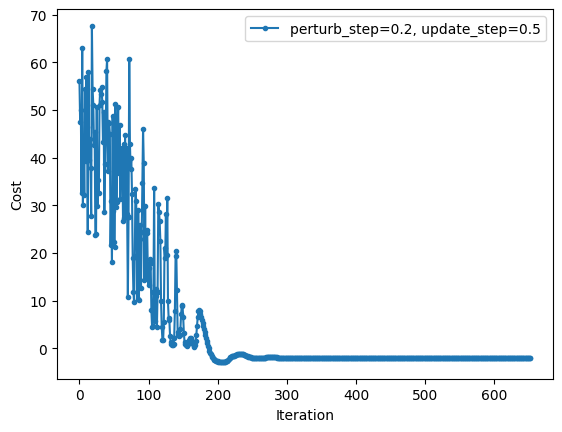

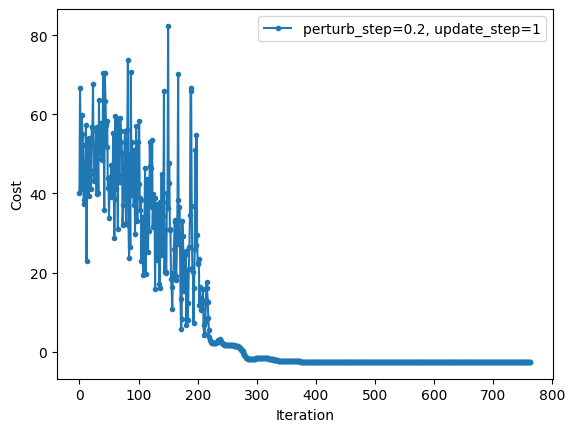

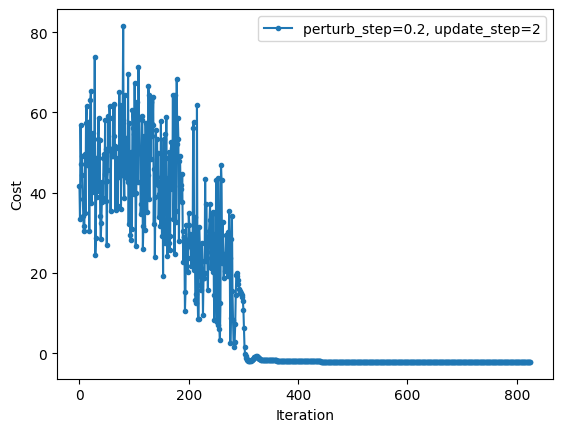

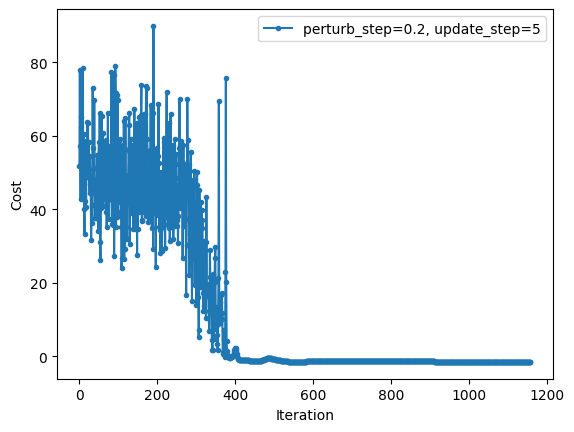

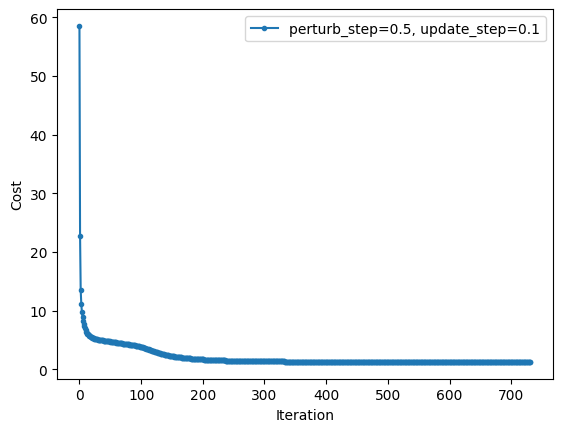

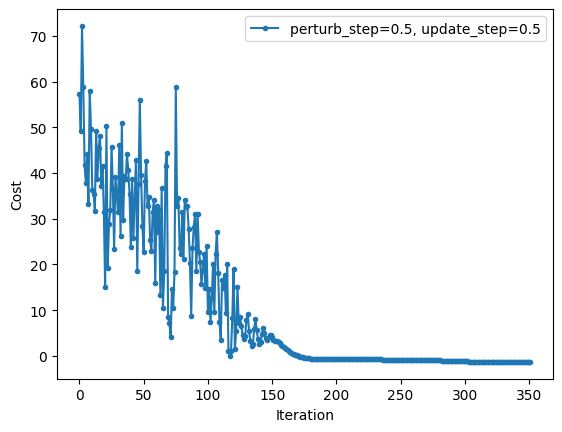

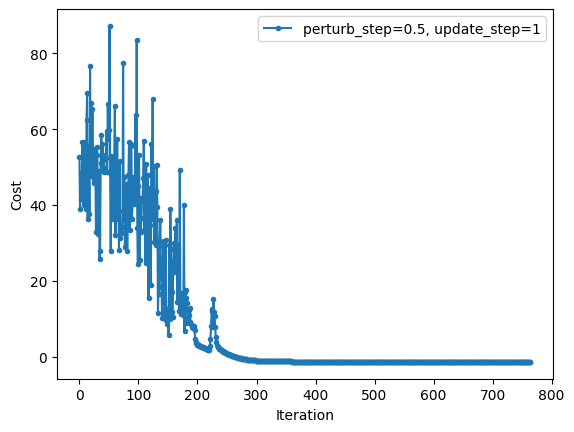

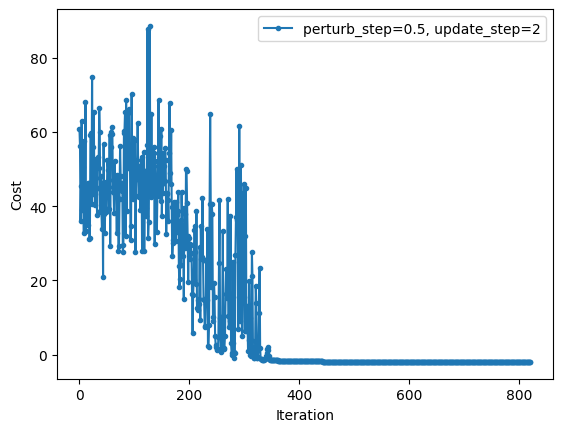

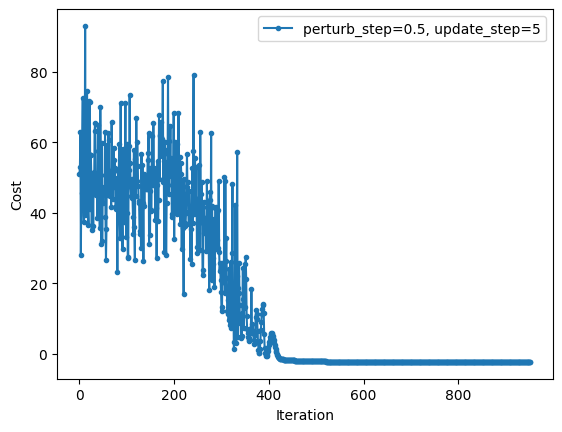

In [16]:
protein_folding_problem = build_pf(main_seq)
qubit_op = protein_folding_problem.qubit_op()

ansatz = TwoLocal(
    qubit_op.num_qubits,
    ["ry"],
    "cx",
    reps=2,
    entanglement="linear",
    skip_final_rotation_layer=True,
)

dir = "vqec_results/step_size_grid_search/"

for filename in sorted(os.listdir(dir)):
    # Check if the file is a JSON file
    if filename.endswith(".json"):
        # Open the JSON file
        with open(os.path.join(dir, filename), "r") as f:
            # Load the JSON data
            data = json.load(f)
            perturb_step = data["primal_perturb_step"]
            update_step = data["primal_dual_update_step"]
            # print(f"update step size = {update_step}, perturb step size = {perturb_step}")
            cost_trajectory = data["energies"]
            # Plot the cost trajectory
            plt.plot(cost_trajectory, label=f"perturb_step={perturb_step}, update_step={update_step}", marker=".")
            plt.xlabel("Iteration")
            plt.ylabel("Cost")
            plt.legend()
            plt.show()

In [17]:
# Loop through the files in the directory
for filename in sorted(os.listdir(dir)):
    # Check if the file is a JSON file
    if filename.endswith(".json"):
        # Open the JSON file
        with open(os.path.join(dir, filename), "r") as f:
            # Load the JSON data
            data = json.load(f)
            perturb_step = data["primal_perturb_step"]
            update_step = data["primal_dual_update_step"]
            print(f"\n perturb_step = {perturb_step}, update_step = {update_step}")
            # Get the optimized variational parameters
            optimal_primal_vars = data["optimal_primal_vars"]
            sorted_quasi_dist = sample_optimized_circ(ansatz, optimal_primal_vars, shots=100000)
            # Compute the energies of all samples
            bitstring_energies = {}
            for i, (sample, prob) in enumerate(sorted_quasi_dist.items()):
                if i >= 5:
                    break
                energy = _evaluate_sparsepauli(sample, qubit_op)
                # Check for overlaps
                overlaps = check_overlaps(peptide, sample)
                turns = convert_bitstring_to_turns(sample, main_seq)
                # Check if the turns exist in the top 20 classical solutions
                top_solns = exists_top_solns(turns, top_cls_turns)
                bitstring_energies[sample] = (turns, energy, prob, overlaps)
                print(f"{sample} (turns: {turns}, top soln: {top_solns}) with probability {prob}, energy {energy}, and overlaps {overlaps}")


 perturb_step = 0.01, update_step = 0.1


/var/folders/6z/68dj05v5057cwh6yv32zx6380000gp/T/ipykernel_47850/1149099428.py:39: DeprecationWarning: The class ``qiskit.primitives.sampler.Sampler`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseSamplerV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Sampler` class is `StatevectorSampler`.
  sampler = Sampler(options={"shots": shots})


110100111100100000011011 (turns: 90720, top soln: None) with probability 0.01967, energy -1.1320000000000017, and overlaps [(2, 5)]
110101101100100000011011 (turns: 90720, top soln: None) with probability 0.01906, energy -2.8680000000000017, and overlaps [(2, 5)]
001011101100100000011011 (turns: 90720, top soln: None) with probability 0.01414, energy -2.0410000000000013, and overlaps [(2, 5)]
110101101101100000011011 (turns: 70720, top soln: None) with probability 0.01242, energy 0.7999999999999983, and overlaps None
001010111100100000011011 (turns: 90720, top soln: None) with probability 0.01233, energy -0.30500000000000094, and overlaps [(2, 5)]

 perturb_step = 0.01, update_step = 0.5
001110011111100001101010 (turns: b8590, top soln: None) with probability 0.08987, energy -2.096999999999999, and overlaps [(0, 5)]
001110111111100001101010 (turns: b8590, top soln: None) with probability 0.08766, energy -2.4899999999999993, and overlaps [(0, 5)]
001110111011100001101010 (turns: b8590, 

In [18]:
print(convert_bitstring_to_turns("011110101011010000111010", main_seq))
print(convert_bitstring_to_turns("001100011100011001110010", main_seq))

a0b90
84190


### p = 0.2, u = 0.5

In [8]:
dir = "vqec_results/klvffa_vqec_p0_2_u0_5"
filename = "klvffa_vqec_res_00.json"
with open(f"{dir}/{filename}", "r") as f:
    data = json.load(f)
data.keys()

dict_keys(['primal_perturb_step', 'dual_perturb_step', 'primal_dual_update_step', 'energies', 'constraints', 'dual_vars_history', 'lagrangian_gap_trajectory', 'optimal_primal_vars', 'optimal_dual_vars', 'vqec_iterations'])

[[ 0.   -3.37 -2.49 -3.36 -3.36 -1.31]
 [ 0.    0.   -6.48 -7.28 -7.28 -4.91]
 [ 0.    0.    0.   -6.29 -6.29 -4.04]
 [ 0.    0.    0.    0.   -7.26 -4.81]
 [ 0.    0.    0.    0.    0.   -4.81]
 [ 0.    0.    0.    0.    0.    0.  ]]


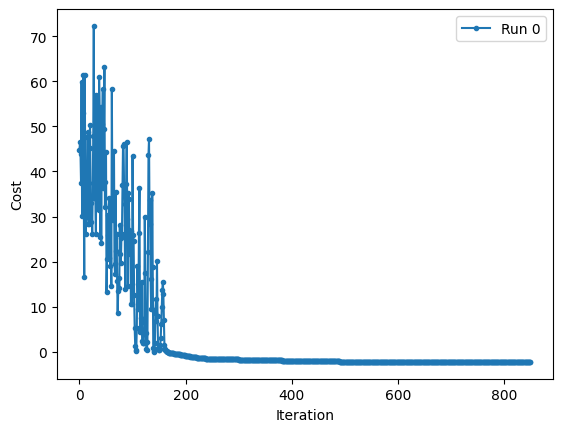

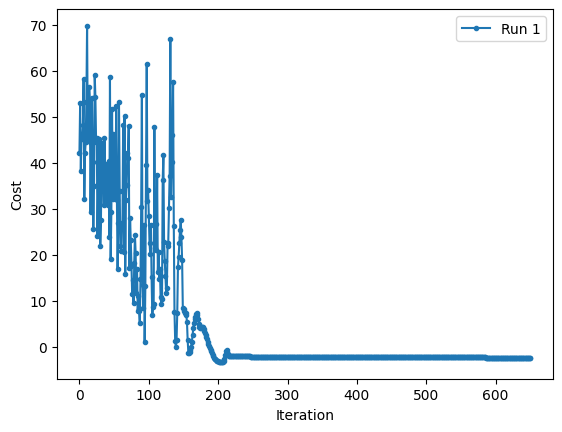

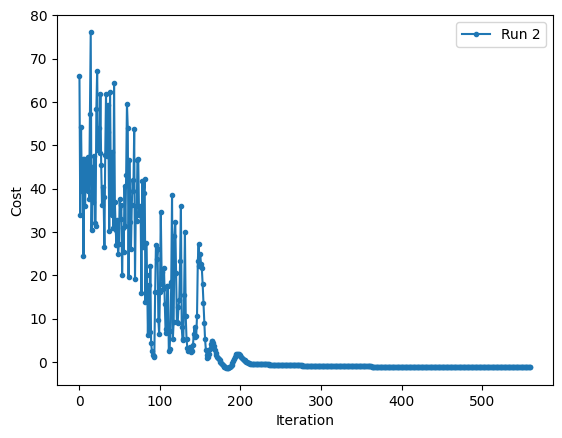

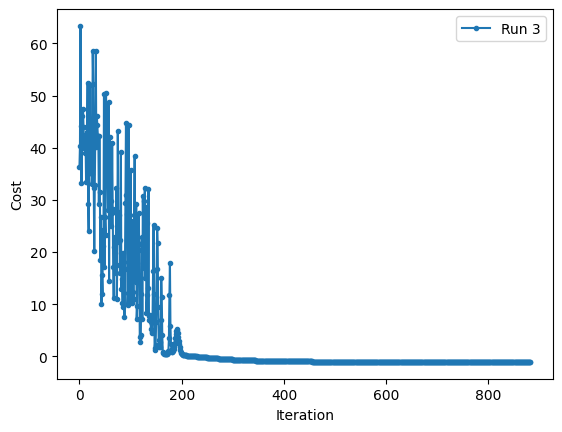

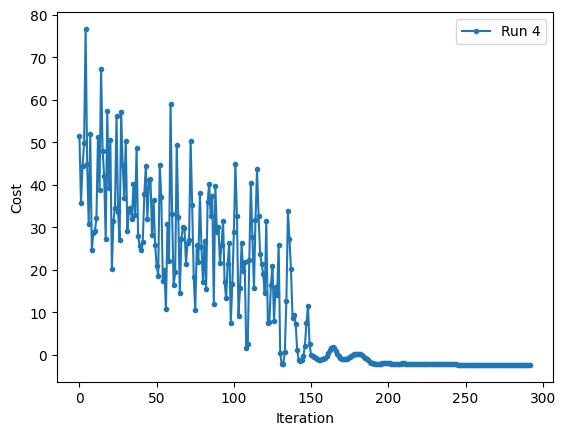

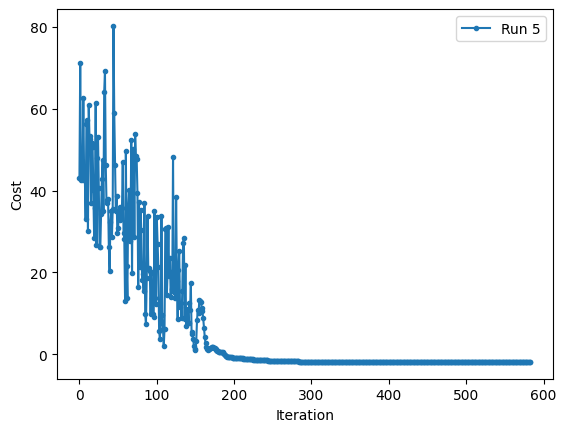

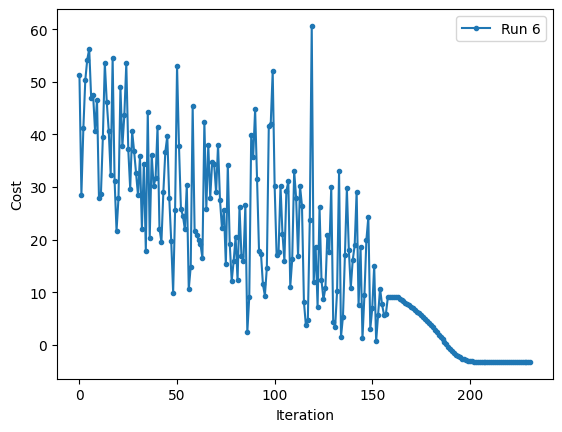

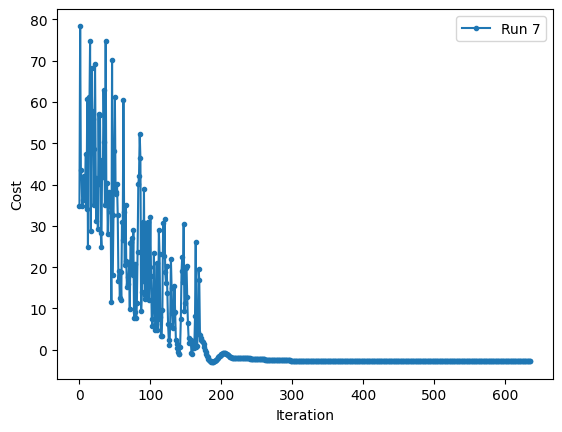

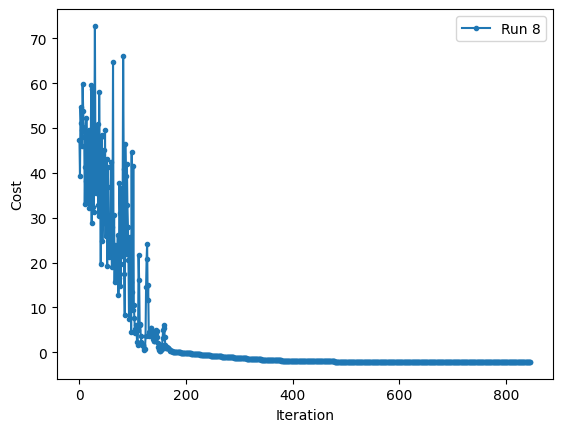

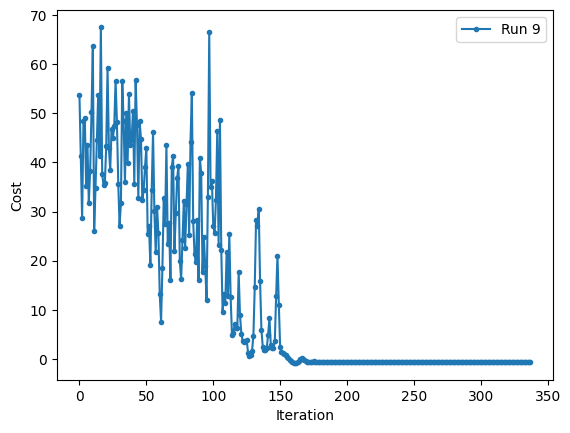

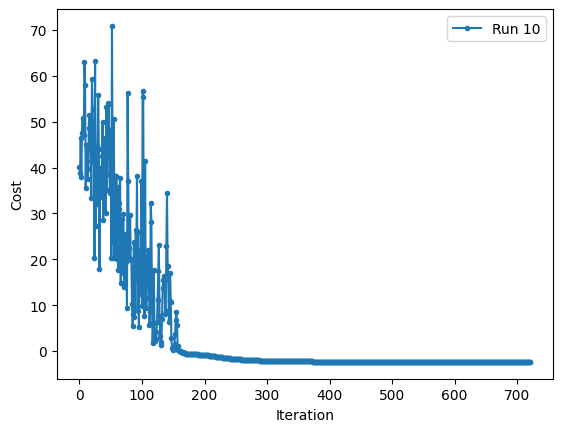

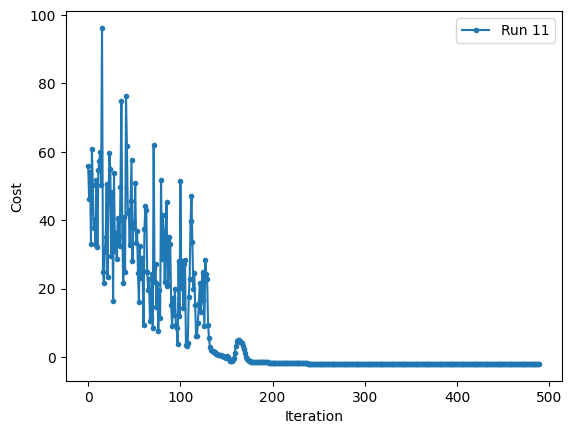

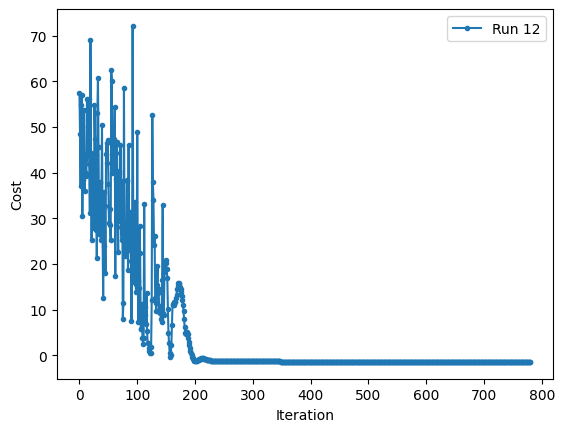

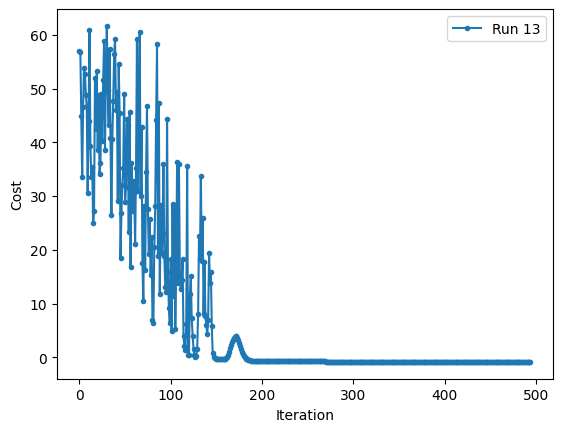

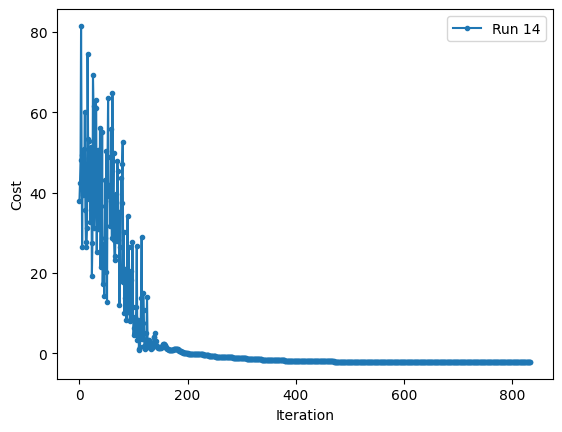

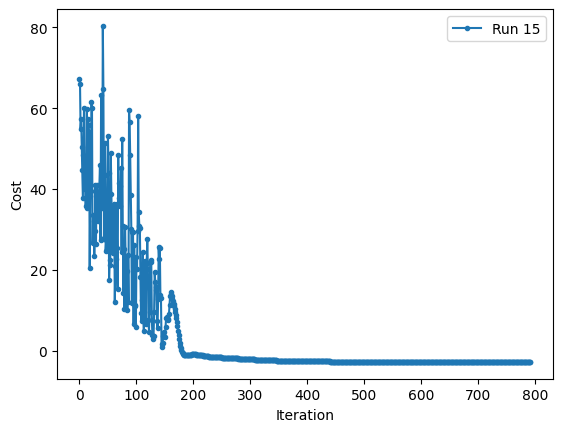

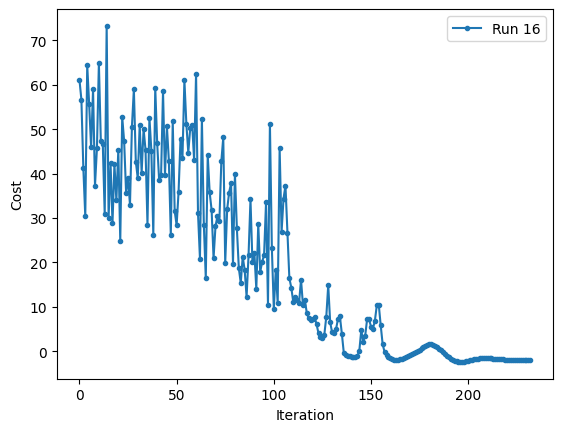

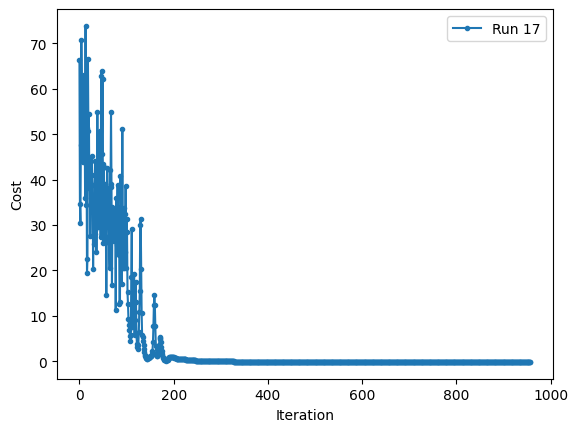

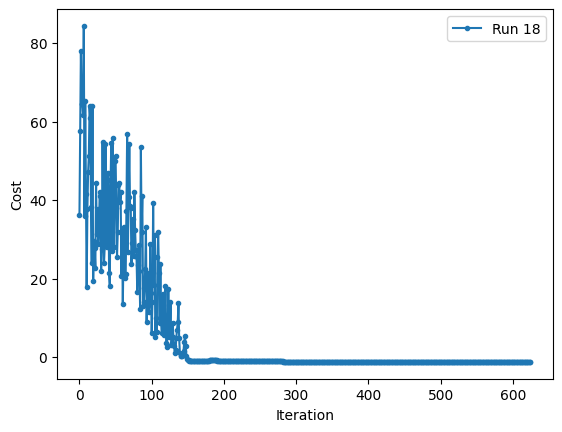

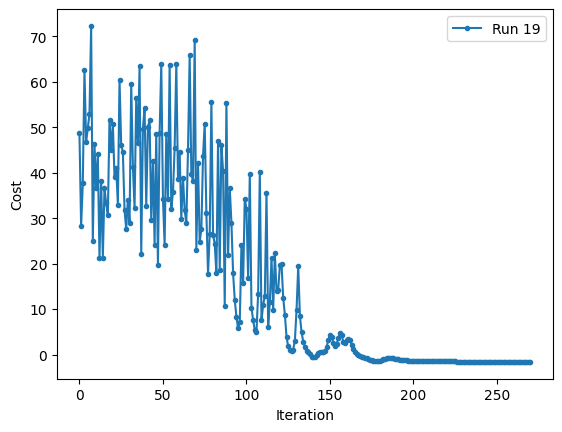

In [18]:
protein_folding_problem = build_pf(main_seq)
qubit_op = protein_folding_problem.qubit_op()

ansatz = TwoLocal(
    qubit_op.num_qubits,
    ["ry"],
    "cx",
    reps=2,
    entanglement="linear",
    skip_final_rotation_layer=True,
)

dir = "vqec_results/klvffa_vqec_p0_2_u0_5/"

for i, filename in enumerate(sorted(os.listdir(dir))):
    # Check if the file is a JSON file
    if filename.endswith(".json"):
        # Open the JSON file
        with open(os.path.join(dir, filename), "r") as f:
            # Load the JSON data
            data = json.load(f)
            cost_trajectory = data["energies"]
            # Plot the cost trajectory
            plt.plot(cost_trajectory, label=f"Run {i}", marker=".")
            plt.xlabel("Iteration")
            plt.ylabel("Cost")
            plt.legend()
            plt.show()

In [20]:
# Loop through the files in the directory
for i, filename in enumerate(sorted(os.listdir(dir))):
    # Check if the file is a JSON file
    if filename.endswith(".json"):
        # Open the JSON file
        with open(os.path.join(dir, filename), "r") as f:
            print(f"Run {i}:")
            # Load the JSON data
            data = json.load(f)
            # Get the optimized variational parameters
            optimal_primal_vars = data["optimal_primal_vars"]
            sorted_quasi_dist = sample_optimized_circ(ansatz, optimal_primal_vars, shots=100000)
            # Compute the energies of all samples
            bitstring_energies = {}
            for j, (sample, prob) in enumerate(sorted_quasi_dist.items()):
                if j >= 5:
                    break
                energy = _evaluate_sparsepauli(sample, qubit_op)
                # Check for overlaps
                overlaps = check_overlaps(peptide, sample)
                turns = convert_bitstring_to_turns(sample, main_seq)
                # Check if the turns exist in the top 20 classical solutions
                top_solns = exists_top_solns(turns, top_cls_turns)
                bitstring_energies[sample] = (turns, energy, prob, overlaps)
                print(f"{sample} (turns: {turns}, top soln: {top_solns}) with probability {prob}, energy {energy}, and overlaps {overlaps}")

Run 0:


/var/folders/6z/68dj05v5057cwh6yv32zx6380000gp/T/ipykernel_47850/1149099428.py:39: DeprecationWarning: The class ``qiskit.primitives.sampler.Sampler`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseSamplerV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Sampler` class is `StatevectorSampler`.
  sampler = Sampler(options={"shots": shots})


111101100111111110000010 (turns: 3b090, top soln: None) with probability 0.21573, energy -4.095000000000007, and overlaps [(1, 5)]
101101100111111110000010 (turns: 3b090, top soln: None) with probability 0.16072, energy -3.6910000000000065, and overlaps [(1, 5)]
000010011000101110000010 (turns: 9b090, top soln: None) with probability 0.1106, energy 0.6159999999999897, and overlaps None
111101100111010110000010 (turns: a7090, top soln: None) with probability 0.10457, energy -1.7810000000000044, and overlaps [(1, 4)]
010010011000101110000010 (turns: 9b090, top soln: None) with probability 0.08373, energy 0.21199999999998953, and overlaps None
Run 1:
001111000111100001101011 (turns: b8520, top soln: None) with probability 0.09711, energy -3.7830000000000057, and overlaps [(1, 4)]
001110010011100001101011 (turns: b8520, top soln: None) with probability 0.09705, energy -3.6400000000000055, and overlaps [(1, 4)]
011111000111100001101011 (turns: b8520, top soln: None) with probability 0.08213

### p = 0.2, u = 0.1

In [9]:
protein_folding_problem = build_pf(main_seq)
qubit_op = protein_folding_problem.qubit_op()

ansatz = TwoLocal(
    qubit_op.num_qubits,
    ["ry"],
    "cx",
    reps=2,
    entanglement="linear",
    skip_final_rotation_layer=True,
)

dir = "vqec_results/klvffa_vqec_p0_2_u0_1/"

# for i, filename in enumerate(sorted(os.listdir(dir))):
#     # Check if the file is a JSON file
#     if filename.endswith(".json"):
#         # Open the JSON file
#         with open(os.path.join(dir, filename), "r") as f:
#             # Load the JSON data
#             data = json.load(f)
#             cost_trajectory = data["energies"]
#             # Plot the cost trajectory
#             plt.plot(cost_trajectory, label=f"Run {i}", marker=".")
#             plt.xlabel("Iteration")
#             plt.ylabel("Cost")
#             plt.legend()
#             plt.show()


# Loop through the files in the directory
for i, filename in enumerate(sorted(os.listdir(dir))):
    # Check if the file is a JSON file
    if filename.endswith(".json"):
        # Open the JSON file
        with open(os.path.join(dir, filename), "r") as f:
            print(f"Run {i}:")
            # Load the JSON data
            data = json.load(f)
            # Get the optimized variational parameters
            optimal_primal_vars = data["optimal_primal_vars"]
            sorted_quasi_dist = sample_optimized_circ(ansatz, optimal_primal_vars, shots=100000)
            # Compute the energies of all samples
            bitstring_energies = {}
            for j, (sample, prob) in enumerate(sorted_quasi_dist.items()):
                if j >= 5:
                    break
                energy = _evaluate_sparsepauli(sample, qubit_op)
                # Check for overlaps
                overlaps = check_overlaps(peptide, sample)
                turns = convert_bitstring_to_turns(sample, main_seq)
                # Check if the turns exist in the top 20 classical solutions
                top_solns = exists_top_solns(turns, top_cls_turns)
                bitstring_energies[sample] = (turns, energy, prob, overlaps)
                print(f"{sample} (turns: {turns}, top soln: {top_solns}) with probability {prob}, energy {energy}, and overlaps {overlaps}")

[[ 0.   -3.37 -2.49 -3.36 -3.36 -1.31]
 [ 0.    0.   -6.48 -7.28 -7.28 -4.91]
 [ 0.    0.    0.   -6.29 -6.29 -4.04]
 [ 0.    0.    0.    0.   -7.26 -4.81]
 [ 0.    0.    0.    0.    0.   -4.81]
 [ 0.    0.    0.    0.    0.    0.  ]]
Run 0:


/var/folders/6z/68dj05v5057cwh6yv32zx6380000gp/T/ipykernel_21836/1149099428.py:39: DeprecationWarning: The class ``qiskit.primitives.sampler.Sampler`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseSamplerV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Sampler` class is `StatevectorSampler`.
  sampler = Sampler(options={"shots": shots})


110111001100100000011011 (turns: 90720, top soln: None) with probability 0.03174, energy -3.727000000000001, and overlaps [(2, 5)]
110111000100100000011011 (turns: 90720, top soln: None) with probability 0.03161, energy -3.3910000000000027, and overlaps [(2, 5)]
110111100100100000011011 (turns: 90720, top soln: None) with probability 0.03129, energy -3.260000000000003, and overlaps [(2, 5)]
110101000100100000011011 (turns: 90720, top soln: None) with probability 0.0308, energy -2.663000000000003, and overlaps [(2, 5)]
110111101100100000011011 (turns: 90720, top soln: None) with probability 0.0306, energy -3.5960000000000014, and overlaps [(2, 5)]
Run 1:
000001100001101010011000 (turns: 75700, top soln: None) with probability 0.02385, energy -0.33500000000000885, and overlaps None
000011000001100010011000 (turns: 79700, top soln: None) with probability 0.0229, energy -2.9120000000000097, and overlaps [(1, 4)]
000001100001100010011000 (turns: 79700, top soln: None) with probability 0.022

### p = 0.5, u = 1.0

In [10]:
protein_folding_problem = build_pf(main_seq)
qubit_op = protein_folding_problem.qubit_op()

ansatz = TwoLocal(
    qubit_op.num_qubits,
    ["ry"],
    "cx",
    reps=2,
    entanglement="linear",
    skip_final_rotation_layer=True,
)

dir = "vqec_results/klvffa_vqec_p0_5_u1/"


# Loop through the files in the directory
for i, filename in enumerate(sorted(os.listdir(dir))):
    # Check if the file is a JSON file
    if filename.endswith(".json"):
        # Open the JSON file
        with open(os.path.join(dir, filename), "r") as f:
            print(f"Run {i}:")
            # Load the JSON data
            data = json.load(f)
            # Get the optimized variational parameters
            optimal_primal_vars = data["optimal_primal_vars"]
            sorted_quasi_dist = sample_optimized_circ(ansatz, optimal_primal_vars, shots=100000)
            # Compute the energies of all samples
            bitstring_energies = {}
            for j, (sample, prob) in enumerate(sorted_quasi_dist.items()):
                if j >= 5:
                    break
                energy = _evaluate_sparsepauli(sample, qubit_op)
                # Check for overlaps
                overlaps = check_overlaps(peptide, sample)
                turns = convert_bitstring_to_turns(sample, main_seq)
                # Check if the turns exist in the top 20 classical solutions
                top_solns = exists_top_solns(turns, top_cls_turns)
                bitstring_energies[sample] = (turns, energy, prob, overlaps)
                print(f"{sample} (turns: {turns}, top soln: {top_solns}) with probability {prob}, energy {energy}, and overlaps {overlaps}")

[[ 0.   -3.37 -2.49 -3.36 -3.36 -1.31]
 [ 0.    0.   -6.48 -7.28 -7.28 -4.91]
 [ 0.    0.    0.   -6.29 -6.29 -4.04]
 [ 0.    0.    0.    0.   -7.26 -4.81]
 [ 0.    0.    0.    0.    0.   -4.81]
 [ 0.    0.    0.    0.    0.    0.  ]]
Run 0:


/var/folders/6z/68dj05v5057cwh6yv32zx6380000gp/T/ipykernel_21836/1149099428.py:39: DeprecationWarning: The class ``qiskit.primitives.sampler.Sampler`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseSamplerV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Sampler` class is `StatevectorSampler`.
  sampler = Sampler(options={"shots": shots})


011110100000111100110101 (turns: 21a80, top soln: None) with probability 0.23266, energy -3.365000000000001, and overlaps [(1, 5)]
010110100000111100110101 (turns: 21a80, top soln: None) with probability 0.21659, energy -2.736000000000001, and overlaps [(1, 5)]
100001011111011100110101 (turns: a1a80, top soln: None) with probability 0.11505, energy 3.6819999999999955, and overlaps None
101001011111011100110101 (turns: a1a80, top soln: None) with probability 0.10708, energy 3.0529999999999955, and overlaps None
011100100000111100110101 (turns: 21a80, top soln: None) with probability 0.09531, energy -2.6370000000000013, and overlaps [(1, 5)]
Run 1:
000110100101100010110101 (turns: 79a80, top soln: None) with probability 0.09234, energy -0.34100000000001773, and overlaps None
010110100111100010110101 (turns: b9a80, top soln: None) with probability 0.09207, energy -1.98900000000002, and overlaps [(1, 5)]
010110100101100010110101 (turns: 79a80, top soln: None) with probability 0.09095, ener

### p = 0.5, u = 2.0

In [11]:
protein_folding_problem = build_pf(main_seq)
qubit_op = protein_folding_problem.qubit_op()

ansatz = TwoLocal(
    qubit_op.num_qubits,
    ["ry"],
    "cx",
    reps=2,
    entanglement="linear",
    skip_final_rotation_layer=True,
)

dir = "vqec_results/klvffa_vqec_p0_5_u2/"


# Loop through the files in the directory
for i, filename in enumerate(sorted(os.listdir(dir))):
    # Check if the file is a JSON file
    if filename.endswith(".json"):
        # Open the JSON file
        with open(os.path.join(dir, filename), "r") as f:
            print(f"Run {i}:")
            # Load the JSON data
            data = json.load(f)
            # Get the optimized variational parameters
            optimal_primal_vars = data["optimal_primal_vars"]
            sorted_quasi_dist = sample_optimized_circ(ansatz, optimal_primal_vars, shots=100000)
            # Compute the energies of all samples
            bitstring_energies = {}
            for j, (sample, prob) in enumerate(sorted_quasi_dist.items()):
                if j >= 5:
                    break
                energy = _evaluate_sparsepauli(sample, qubit_op)
                # Check for overlaps
                overlaps = check_overlaps(peptide, sample)
                turns = convert_bitstring_to_turns(sample, main_seq)
                # Check if the turns exist in the top 20 classical solutions
                top_solns = exists_top_solns(turns, top_cls_turns)
                bitstring_energies[sample] = (turns, energy, prob, overlaps)
                print(f"{sample} (turns: {turns}, top soln: {top_solns}) with probability {prob}, energy {energy}, and overlaps {overlaps}")

[[ 0.   -3.37 -2.49 -3.36 -3.36 -1.31]
 [ 0.    0.   -6.48 -7.28 -7.28 -4.91]
 [ 0.    0.    0.   -6.29 -6.29 -4.04]
 [ 0.    0.    0.    0.   -7.26 -4.81]
 [ 0.    0.    0.    0.    0.   -4.81]
 [ 0.    0.    0.    0.    0.    0.  ]]
Run 0:


/var/folders/6z/68dj05v5057cwh6yv32zx6380000gp/T/ipykernel_21836/1149099428.py:39: DeprecationWarning: The class ``qiskit.primitives.sampler.Sampler`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseSamplerV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Sampler` class is `StatevectorSampler`.
  sampler = Sampler(options={"shots": shots})


010110111111010001111010 (turns: a8b90, top soln: None) with probability 0.11235, energy -3.657000000000019, and overlaps [(1, 5)]
011100111111010001111010 (turns: a8b90, top soln: None) with probability 0.11053, energy -2.30000000000002, and overlaps [(1, 5)]
011100111011010001111010 (turns: a8b90, top soln: None) with probability 0.1056, energy -2.0510000000000193, and overlaps [(1, 5)]
010110111011010001111010 (turns: a8b90, top soln: None) with probability 0.10509, energy -3.4080000000000186, and overlaps [(1, 5)]
011100111111010001110010 (turns: a8190, top soln: None) with probability 0.07385, energy -3.248000000000008, and overlaps [(0, 4)]
Run 1:
110110111111010001111010 (turns: a8b90, top soln: None) with probability 0.03929, energy -3.1760000000000193, and overlaps [(1, 5)]
110110111011010001111010 (turns: a8b90, top soln: None) with probability 0.03859, energy -2.9270000000000187, and overlaps [(1, 5)]
110100111111010001111010 (turns: a8b90, top soln: None) with probability 0

### p = 0.5, u = 5.0 (Found the 1st excited state!)

In [12]:
protein_folding_problem = build_pf(main_seq)
qubit_op = protein_folding_problem.qubit_op()

ansatz = TwoLocal(
    qubit_op.num_qubits,
    ["ry"],
    "cx",
    reps=2,
    entanglement="linear",
    skip_final_rotation_layer=True,
)

dir = "vqec_results/klvffa_vqec_p0_5_u5/"


# Loop through the files in the directory
for i, filename in enumerate(sorted(os.listdir(dir))):
    # Check if the file is a JSON file
    if filename.endswith(".json"):
        # Open the JSON file
        with open(os.path.join(dir, filename), "r") as f:
            print(f"Run {i}:")
            # Load the JSON data
            data = json.load(f)
            # Get the optimized variational parameters
            optimal_primal_vars = data["optimal_primal_vars"]
            sorted_quasi_dist = sample_optimized_circ(ansatz, optimal_primal_vars, shots=100000)
            # Compute the energies of all samples
            bitstring_energies = {}
            for j, (sample, prob) in enumerate(sorted_quasi_dist.items()):
                if j >= 5:
                    break
                energy = _evaluate_sparsepauli(sample, qubit_op)
                # Check for overlaps
                overlaps = check_overlaps(peptide, sample)
                turns = convert_bitstring_to_turns(sample, main_seq)
                # Check if the turns exist in the top 20 classical solutions
                top_solns = exists_top_solns(turns, top_cls_turns)
                bitstring_energies[sample] = (turns, energy, prob, overlaps)
                print(f"{sample} (turns: {turns}, top soln: {top_solns}) with probability {prob}, energy {energy}, and overlaps {overlaps}")

[[ 0.   -3.37 -2.49 -3.36 -3.36 -1.31]
 [ 0.    0.   -6.48 -7.28 -7.28 -4.91]
 [ 0.    0.    0.   -6.29 -6.29 -4.04]
 [ 0.    0.    0.    0.   -7.26 -4.81]
 [ 0.    0.    0.    0.    0.   -4.81]
 [ 0.    0.    0.    0.    0.    0.  ]]
Run 0:


/var/folders/6z/68dj05v5057cwh6yv32zx6380000gp/T/ipykernel_21836/1149099428.py:39: DeprecationWarning: The class ``qiskit.primitives.sampler.Sampler`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseSamplerV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Sampler` class is `StatevectorSampler`.
  sampler = Sampler(options={"shots": shots})


001001000100101110000010 (turns: 9b090, top soln: None) with probability 0.1324, energy -1.606000000000011, and overlaps None
001001000000101110000010 (turns: 9b090, top soln: None) with probability 0.13001, energy -1.3570000000000109, and overlaps None
000011000100101110000010 (turns: 9b090, top soln: None) with probability 0.07426, energy -1.7050000000000114, and overlaps None
000011000000101110000010 (turns: 9b090, top soln: None) with probability 0.07364, energy -1.4560000000000113, and overlaps None
001011000100101110000010 (turns: 9b090, top soln: None) with probability 0.06752, energy -2.334000000000011, and overlaps None
Run 1:
010000001000011101001110 (turns: 8a290, top soln: None) with probability 0.22917, energy 0.6039999999999914, and overlaps None
010000001100011101001110 (turns: 8a290, top soln: None) with probability 0.22748, energy 0.3549999999999909, and overlaps None
000000001100011101001110 (turns: 8a290, top soln: None) with probability 0.21516, energy 0.75899999999

## Miscellaneous

In [11]:
ansatz = TwoLocal(qubit_op.num_qubits, ['ry'], 'cx', reps=1, entanglement='linear', skip_final_rotation_layer=True)
init_params = [np.random.rand(ansatz.num_parameters)]
# estimator = Estimator(backend_options={'method': 'statevector'})
estimator = Estimator(backend_options={'method': 'matrix_product_state'}, run_options={'shots': None}, approximation=True)
gradient_1 = LinCombEstimatorGradient(estimator=estimator)
gradient_2 = ParamShiftEstimatorGradient(estimator=estimator)
gradient_3 = FiniteDiffEstimatorGradient(estimator=estimator, epsilon=0.001)

In [16]:
grad_result_1 = gradient_1.run(circuits=ansatz, observables=qubit_op, parameter_values=init_params)
grad_result_1.result().gradients

[array([-24.6522316 ,  -8.3543522 , -15.33924042, -17.66810352,
        -24.91474543,  -5.3918116 ,  -7.38997048,  -0.99347861,
        -21.46319724, -18.40985139,   8.06716479,  -2.99647204,
         -0.88005039,  17.75540077,   1.55650454,  25.54264364,
         12.80644996,   4.51805965,  11.71222944,   4.05098697,
          6.9476704 ,   0.59124748,   0.2470542 ,   0.15424398])]

In [14]:
grad_result_2 = gradient_2.run(circuits=ansatz, observables=qubit_op, parameter_values=init_params)
grad_result_2.result().gradients

[array([-24.6522316 ,  -8.3543522 , -15.33924042, -17.66810352,
        -24.91474543,  -5.3918116 ,  -7.38997048,  -0.99347861,
        -21.46319724, -18.40985139,   8.06716479,  -2.99647204,
         -0.88005039,  17.75540077,   1.55650454,  25.54264364,
         12.80644996,   4.51805965,  11.71222944,   4.05098697,
          6.9476704 ,   0.59124748,   0.2470542 ,   0.154244  ])]

In [13]:
grad_result_3 = gradient_3.run(circuits=ansatz, observables=qubit_op, parameter_values=init_params)
grad_result_3.result().gradients

[array([-24.6522275 ,  -8.3543508 , -15.33923786, -17.66810057,
        -24.91474127,  -5.39181071,  -7.38996925,  -0.99347845,
        -21.46319366, -18.40984832,   8.06716344,  -2.99647154,
         -0.88005024,  17.75539781,   1.55650428,  25.54263939,
         12.80644782,   4.5180589 ,  11.71222749,   4.05098629,
          6.94766924,   0.59124738,   0.24705416,   0.15424398])]